# Работа с базами данных

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. Лекция "Работа с базами данных"
* https://sqliteonline.com/
* https://docs.python.org/3/library/sqlite3.html
* https://www.sqlitetutorial.net/sqlite-create-table/
* https://docs.python.org/3/library/pickle.html
* https://www.geeksforgeeks.org/sql-join-set-1-inner-left-right-and-full-joins/
* https://www.datacamp.com/community/tutorials/group-by-having-clause-sql

## Задачи для совместного разбора

In [1]:
import pandas as pd
import sqlite3

In [2]:
students = pd.DataFrame(
    [
        ("Сотников Евгений Янович", 1),
        ("Степанова Виктория Константиновна", 1),
        ("Горелова Вероника Яновна", 2),
        ("Гришин Иван Романович", 3),
    ],
    columns=["name", "group_id"],
)


groups = list(zip([1, 2, 3], ["ПМ20-1", "ПМ20-2", "ПМ20-3"]))

In [10]:
con = sqlite3.connect('new_demo.db')

In [11]:
sql = '''
CREATE TABLE StudentGroup (
    id INT PRIMARY KEY,
    name VARCHAR    
);

CREATE TABLE Student (
    name VARCHAR PRIMARY KEY,
    group_id INT,
    FOREIGN KEY (group_id) REFERENCES StudentGroup(id)
);
'''

In [12]:
cur = con.cursor()

In [13]:
#Метод cursor.execute() выполняет команду SQL. 
# Команды SQL могут быть параметризованными, 
# то есть передаются заполнители вместо литералов SQL.
#Модуль sqlite3 поддерживает два вида заполнителей: 
# вопросительные знаки '?' - стиль qmark и именованные заполнители.

In [14]:
cur.executescript(sql)
con.commit()

1. Создайте БД sqlite3 и таблицы Student и StudentGroup в ней.

2. Заполните созданные таблицы данными

In [15]:
sql = '''
INSERT INTO StudentGroup(id, name) VALUES (?, ?);
'''

# cur.executre(sql, (1, "ПМ21-1"))
# cur.executre(sql, (2, "ПМ21-2"))
# cur.executre(sql, (3, "ПМ21-3"))
# for group in groups:
#     cur.execute(sql, group)

cur.executemany(sql, groups)
con.commit()

In [16]:
students

,name,group_id
0,Сотников Евгений Янович,1
1,Степанова Виктория Константиновна,1
2,Горелова Вероника Яновна,2
3,Гришин Иван Романович,3


In [17]:
students.to_sql('Student', con, if_exists='append', index=False)

3. Выведите на экран фамилии студентов и номера их групп.

In [18]:
r = cur.execute('SELECT * FROM StudentGroup;')
# r.fetchone()
# r.fetchmany(2)
r.fetchall()

[(1, 'ПМ20-1'), (2, 'ПМ20-2'), (3, 'ПМ20-3')]

In [19]:
pd.read_sql_query('SELECT * FROM Student;', con)

,name,group_id
0,Сотников Евгений Янович,1
1,Степанова Виктория Константиновна,1
2,Горелова Вероника Яновна,2
3,Гришин Иван Романович,3


## Лабораторная работа 9

### Создание и заполнение базы данных

1\. Создайте файл БД sqlite3 согласно рисунку ниже, на котором определен набор таблиц и связей между ними. Обратите внимание, что поля, выделенные полужирным шрифтом, обозначают первичный ключ таблицы.

Для решения задания напишите скрипт на языке SQL и исполните его при помощи метода `executescript` объекта-курсора.

In [20]:
con = sqlite3.connect('database.db')

In [37]:
sql = '''
CREATE TABLE IF NOT EXISTS Recipe (
    id INT PRIMARY KEY,
    name VARCHAR,
    minutes INT,
    submitted VARCHAR,
    description TEXT,
    n_ingridients INT
);

CREATE TABLE IF NOT EXISTS TAG (
    tag VARCHAR,
    recipe_id INT,
    PRIMARY KEY (tag, recipe_id),
    FOREIGN KEY (recipe_id) REFERENCES Recipe(id) 
);

CREATE TABLE IF NOT EXISTS Review (
    id INT PRIMARY KEY,
    user_id INT,
    recipe_id INT,
    date VARCHAR,
    rating INT,
    review TEXT,
    FOREIGN KEY (recipe_id) REFERENCES Recipe(id)
);

CREATE TABLE IF NOT EXISTS Ingredient (
ingredient_name VARCHAR PRIMARY KEY,
recipe_id INT,
FOREIGN KEY (recipe_id) REFERENCES Recipe(id)
);
'''

In [38]:
cur = con.cursor()

In [39]:
cur.executescript(sql)
con.commit()

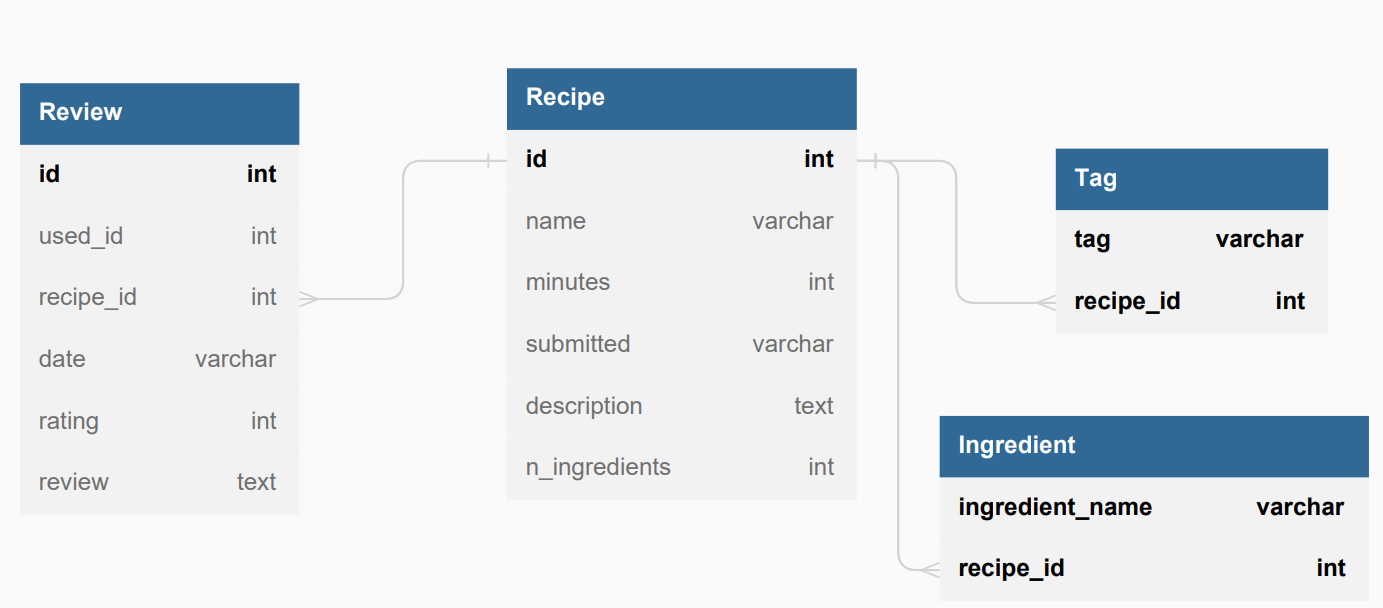

2\. Загрузите данные из файла `recipes_sample.csv` в таблицу `Recipe`. При выполнении задания воспользуйтесь методом `executemany` объекта-курсора.

In [44]:
recipe = pd.read_csv('09_database_data/recipes_sample.csv')
recipe.head()

,name,id,minutes,contributor_id,submitted,n_steps,description,n_ingredients
0,george s at the cove black bean soup,44123,90,35193,2002-10-25,NaN,an original recipe created by chef scott meska...,18.0
1,healthy for them yogurt popsicles,67664,10,91970,2003-07-26,NaN,my children and their friends ask for my homem...,NaN
2,i can t believe it s spinach,38798,30,1533,2002-08-29,NaN,"these were so go, it surprised even me.",8.0
3,italian gut busters,35173,45,22724,2002-07-27,NaN,my sister-in-law made these for us at a family...,NaN
4,love is in the air beef fondue sauces,84797,25,4470,2004-02-23,4.0,i think a fondue is a very romantic casual din...,NaN


In [46]:
recipe = recipe[["id", "name", "minutes", "submitted", "description", "n_ingredients"]]
recipe.head()

,id,name,minutes,submitted,description,n_ingredients
0,44123,george s at the cove black bean soup,90,2002-10-25,an original recipe created by chef scott meska...,18.0
1,67664,healthy for them yogurt popsicles,10,2003-07-26,my children and their friends ask for my homem...,NaN
2,38798,i can t believe it s spinach,30,2002-08-29,"these were so go, it surprised even me.",8.0
3,35173,italian gut busters,45,2002-07-27,my sister-in-law made these for us at a family...,NaN
4,84797,love is in the air beef fondue sauces,25,2004-02-23,i think a fondue is a very romantic casual din...,NaN


In [47]:
cur = con.cursor()

In [48]:
sql = '''
INSERT INTO Recipe(id, name, minutes, submitted, description, n_ingridients) VALUES (?, ?, ?, ?, ?, ?);
'''
cur.executemany(sql, recipe.values.tolist())
con.commit()

In [49]:
pd.read_sql_query('SELECT * FROM Recipe;', con)

,id,name,minutes,submitted,description,n_ingridients
0,44123,george s at the cove black bean soup,90,2002-10-25,an original recipe created by chef scott meska...,18.0
1,67664,healthy for them yogurt popsicles,10,2003-07-26,my children and their friends ask for my homem...,NaN
2,38798,i can t believe it s spinach,30,2002-08-29,"these were so go, it surprised even me.",8.0
3,35173,italian gut busters,45,2002-07-27,my sister-in-law made these for us at a family...,NaN
4,84797,love is in the air beef fondue sauces,25,2004-02-23,i think a fondue is a very romantic casual din...,NaN
...,...,...,...,...,...,...
29995,267661,zurie s holey rustic olive and cheddar bread,80,2007-11-25,this is based on a french recipe but i changed...,10.0
29996,386977,zwetschgenkuchen bavarian plum cake,240,2009-08-24,"this is a traditional fresh plum cake, thought...",11.0
29997,103312,zwiebelkuchen southwest german onion cake,75,2004-11-03,this is a traditional late summer early fall s...,NaN
29998,486161,zydeco soup,60,2012-08-29,this is a delicious soup that i originally fou...,NaN


3\. Загрузите данные из файла `tags_sample.pickle` в таблицу `Tag`. При выполнении задания воспользуйтесь методом `executemany` объекта-курсора. Для считывания файла с данными воспользуйтесь пакетом `pickle`. Обратите внимание, что перед добавлением записей в базу данные нужно привести к соответствующему таблице в БД виду (в каждой строчке столбца tag должен находиться один тэг).

In [50]:
import pickle 

In [56]:
tag = pickle.load(open('09_database_data/tags_sample.pickle', 'rb'))

In [57]:
tag

[{'id': 48,
  'tag': {'4-hours-or-less',
   'american',
   'course',
   'cuisine',
   'desserts',
   'dietary',
   'eggs-dairy',
   'equipment',
   'main-ingredient',
   'north-american',
   'oven',
   'pies',
   'pies-and-tarts',
   'preparation',
   'time-to-make',
   'weeknight'}},
 {'id': 55,
  'tag': {'3-steps-or-less',
   '4-hours-or-less',
   '5-ingredients-or-less',
   'american',
   'appetizers',
   'course',
   'cuisine',
   'dietary',
   'dips',
   'easy',
   'healthy',
   'healthy-2',
   'low-carb',
   'low-cholesterol',
   'low-in-something',
   'low-protein',
   'low-sodium',
   'mexican',
   'no-cook',
   'north-american',
   'occasion',
   'preparation',
   'southwestern-united-states',
   'technique',
   'time-to-make',
   'weeknight'}},
 {'id': 66,
  'tag': {'3-steps-or-less',
   '30-minutes-or-less',
   'american',
   'condiments-etc',
   'course',
   'cuisine',
   'dietary',
   'easy',
   'equipment',
   'free-of-something',
   'healthy',
   'healthy-2',
   'lactose

In [58]:
Tag = []
for i in tag:
    for j in i['tag']:
        Tag.append((j, i['id']))
Tag

[('time-to-make', 48),
 ('dietary', 48),
 ('main-ingredient', 48),
 ('pies', 48),
 ('preparation', 48),
 ('course', 48),
 ('cuisine', 48),
 ('desserts', 48),
 ('weeknight', 48),
 ('oven', 48),
 ('4-hours-or-less', 48),
 ('pies-and-tarts', 48),
 ('eggs-dairy', 48),
 ('american', 48),
 ('equipment', 48),
 ('north-american', 48),
 ('appetizers', 55),
 ('time-to-make', 55),
 ('course', 55),
 ('no-cook', 55),
 ('5-ingredients-or-less', 55),
 ('technique', 55),
 ('weeknight', 55),
 ('occasion', 55),
 ('american', 55),
 ('north-american', 55),
 ('3-steps-or-less', 55),
 ('preparation', 55),
 ('southwestern-united-states', 55),
 ('cuisine', 55),
 ('mexican', 55),
 ('low-protein', 55),
 ('low-sodium', 55),
 ('low-carb', 55),
 ('easy', 55),
 ('dietary', 55),
 ('low-in-something', 55),
 ('dips', 55),
 ('4-hours-or-less', 55),
 ('low-cholesterol', 55),
 ('healthy-2', 55),
 ('healthy', 55),
 ('time-to-make', 66),
 ('course', 66),
 ('occasion', 66),
 ('low-calorie', 66),
 ('american', 66),
 ('equipm

In [59]:
Tag = pd.DataFrame(Tag, columns = ['tag', 'recipe_id'])
Tag

,tag,recipe_id
0,time-to-make,48
1,dietary,48
2,main-ingredient,48
3,pies,48
4,preparation,48
...,...,...
533469,for-large-groups,536747
533470,cakes,536747
533471,number-of-servings,536747
533472,desserts,536747


In [68]:
# удалить таблицу TAG если она есть
cur.execute('DROP TABLE IF EXISTS TAG;')
con.commit()

In [66]:
Tag.to_sql("Tag", con, if_exists="append", index=False)

In [73]:
cur.execute('''
 CREATE TABLE IF NOT EXISTS TAG (
    tag VARCHAR,
    recipe_id INT,
   PRIMARY KEY (tag, recipe_id),
    FOREIGN KEY (recipe_id) REFERENCES Recipe(id)
 );
''')
            
con.commit()


In [75]:
sql = '''
INSERT INTO Tag(tag, recipe_id) VALUES (?, ?);
'''
cur.executemany(sql, Tag.values.tolist())
con.commit()

In [76]:
pd.read_sql_query("SELECT * FROM Tag", con)

,tag,recipe_id
0,time-to-make,48
1,dietary,48
2,main-ingredient,48
3,pies,48
4,preparation,48
...,...,...
533469,for-large-groups,536747
533470,cakes,536747
533471,number-of-servings,536747
533472,desserts,536747


4\. Загрузите данные из файла `reviews_sample.csv` в таблицу `Review`. При выполнении задания воспользуйтесь методом `pd.DataFrame.to_sql`.

In [85]:
review = pd.read_csv('09_database_data/reviews_sample.csv', delimiter = ",", index_col=0)
review.head()

,user_id,recipe_id,date,rating,review
370476,21752,57993,2003-05-01,5,Last week whole sides of frozen salmon fillet ...
624300,431813,142201,2007-09-16,5,So simple and so tasty! I used a yellow capsi...
187037,400708,252013,2008-01-10,4,"Very nice breakfast HH, easy to make and yummy..."
706134,2001852463,404716,2017-12-11,5,These are a favorite for the holidays and so e...
312179,95810,129396,2008-03-14,5,Excellent soup! The tomato flavor is just gre...


In [94]:
review = review.reset_index()
review.head()

,index,user_id,recipe_id,date,rating,review
0,370476,21752,57993,2003-05-01,5,Last week whole sides of frozen salmon fillet ...
1,624300,431813,142201,2007-09-16,5,So simple and so tasty! I used a yellow capsi...
2,187037,400708,252013,2008-01-10,4,"Very nice breakfast HH, easy to make and yummy..."
3,706134,2001852463,404716,2017-12-11,5,These are a favorite for the holidays and so e...
4,312179,95810,129396,2008-03-14,5,Excellent soup! The tomato flavor is just gre...


In [96]:
review["id"] = review["index"]
review = review.drop("index", axis=1)
review.head()

,user_id,recipe_id,date,rating,review,id
0,21752,57993,2003-05-01,5,Last week whole sides of frozen salmon fillet ...,370476
1,431813,142201,2007-09-16,5,So simple and so tasty! I used a yellow capsi...,624300
2,400708,252013,2008-01-10,4,"Very nice breakfast HH, easy to make and yummy...",187037
3,2001852463,404716,2017-12-11,5,These are a favorite for the holidays and so e...,706134
4,95810,129396,2008-03-14,5,Excellent soup! The tomato flavor is just gre...,312179


In [100]:
review["id"].astype(int)

0          370476
1          624300
2          187037
3          706134
4          312179
           ...   
126691    1013457
126692     158736
126693    1059834
126694     453285
126695     691207
Name: id, Length: 126696, dtype: int64

In [101]:
review.to_sql("Review", con, if_exists="append", index=False)
review

IntegrityError: UNIQUE constraint failed: Review.id

In [102]:
pd.read_sql_query('SELECT * FROM Review;', con)

,id,user_id,recipe_id,date,rating,review
0,NaN,21752,57993,2003-05-01,5,Last week whole sides of frozen salmon fillet ...
1,NaN,431813,142201,2007-09-16,5,So simple and so tasty! I used a yellow capsi...
2,NaN,400708,252013,2008-01-10,4,"Very nice breakfast HH, easy to make and yummy..."
3,NaN,2001852463,404716,2017-12-11,5,These are a favorite for the holidays and so e...
4,NaN,95810,129396,2008-03-14,5,Excellent soup! The tomato flavor is just gre...
...,...,...,...,...,...,...
886867,1013457.0,1270706,335534,2009-05-17,4,This recipe was great! I made it last night. I...
886868,158736.0,2282344,8701,2012-06-03,0,This recipe is outstanding. I followed the rec...
886869,1059834.0,689540,222001,2008-04-08,5,"Well, we were not a crowd but it was a fabulou..."
886870,453285.0,2000242659,354979,2015-06-02,5,I have been a steak eater and dedicated BBQ gr...


5\. Загрузите данные из файла `ingredients_sample.csv` в таблицу `Ingredients`. При выполнении задания воспользуйтесь методом `DataFrame.to_sql`.

Обратите внимание, перед вызовом метода `to_sql` вам требуется привести фрейм к соответствующему таблице в БД виду.

In [107]:
ingredient = pd.read_csv('09_database_data/ingredients_sample.csv', delimiter = ",")
ingredient.head()

,recipe,ingredients
0,48,cornstarch;milk;eggs;margarine;butter;flour;sa...
1,55,salt;tomatoes;garlic;lime juice;avocados
2,66,onion;worcestershire sauce;ketchup;garlic clov...
3,91,unsalted butter;celery;broccoli floret;oregano...
4,94,brown sugar;vanilla;all-purpose flour;egg;lemo...


### Получение данных из базы

6\. Напишите и выполните запрос на языке SQL, который считает кол-во рецептов, опубликованных в 2010 году и имеющих длину не менее 15 минут. Для выполнения запроса используйте метод `execute` объекта-курсора. Выведите искомое количество на экран.

In [114]:
sql = '''
SELECT COUNT(*) FROM Recipe
WHERE minutes >= 15 AND submitted LIKE '%2010%';
'''

fifth = cur.execute(sql) # execute - выполняет команду SQL
fifth.fetchone()[0] # fetchone - возвращает одну строку из результата запроса

1319

7\. Напишите и выполните запрос на языке SQL, который возращает id рецептов, не имеющих ни одного отзыва отзывов с рейтингом, меньше 4. Для выполнения запроса используйте функцию `pd.read_sql_query`. Выведите полученный результат на экран.

In [115]:
pd.read_sql_query(
    "SELECT id FROM Recipe WHERE id NOT IN (SELECT recipe_id FROM Review WHERE rating < 4)",
    con)

,id
0,55
1,66
2,91
3,94
4,128
...,...
22361,536360
22362,536473
22363,536547
22364,536728


9\. Используя механизмы группировки и объединения, которые предоставляет SQL, выведите на экран названия и количество тегов 5 рецептов, которые имеют наибольшее количество тэгов. При выполнении задания воспользуйтесь методом `execute` объекта-курсора. Измерьте время выполнения работы вашего кода.

Вся необходимая логика (группировки, объединения, выбор топ-5 строк) должна быть реализована на SQL, а не в виде кода на Python.

In [116]:
sql = '''
SELECT name, COUNT(tag) As count FROM Recipe
INNER JOIN Tag ON Recipe.id = Tag.recipe_id
GROUP BY name
ORDER BY count DESC
LIMIT 5;
'''

In [117]:
ninth = cur.execute(sql)
ninth.fetchall()

[('watermelon basket fruit salad', 58),
 ('creamsicle freeze', 56),
 ('twice baked mashed potatoes', 55),
 ('easy poached salmon with dill', 53),
 ('curried crab asparagus cheesy tofu dip', 53)]

10\. Запросите у пользователя id рецепта и верните информацию об этом рецепте. Если рецепт отсутствует, выведите соответствующее сообщение. Для подстановки значения id необходимо воспользоваться специальным синтаксисом, которые предоставляет `sqlite` для этих целей.Продемонстрируйте работоспособность вашего решения.

In [121]:
n = int(input())
sql = '''
SELECT * FROM Recipe WHERE id = ?;
'''
cur.execute(sql, (n,)) # ececute(sql, (n,)) - выполняет команду SQL с параметрами
answer = cur.fetchall()
if len(answer) == 0:
    print("No such id")
else:
    print(answer[0])

(66, 'black coffee barbecue sauce', 30, '1999-09-10', "it's great to know folks like this sauce so much! i wish i could take credit for it but it was adopted after the original member left. thank you, all, just the same.\r\ni have made the recipe with regular brewed coffee but highly recommend the espresso. in a pinch use strong instant if you have nothing else. the acid of the coffee balances the sweetness of the other ingredients.", 11)
